In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load daily product performance data created in SQL
product = pd.read_csv("product_performance.csv")

# Convert Date to datetime format
product["Date"] = pd.to_datetime(product["Date"])

# Check dataset structure
print("Dataset shape:", product.shape)
product.head()

Dataset shape: (64213, 15)


,Date,Year,Quarter,Month_Number,Month_Name,Product_ID,Product_Name,Product_Category,Product_Cost,Product_Price,Units_Sold,Revenue,COGS,Gross_Profit,Gross_Margin
0,2025-01-01,2025,1,1,January,1,Classic Board Game,Building Blocks,11.86,23.39,3,70.17,35.58,34.59,0.492946
1,2025-01-01,2025,1,1,January,2,Pro Puzzle Pack,Arts & Crafts,8.36,15.54,6,93.24,50.16,43.08,0.462033
2,2025-01-01,2025,1,1,January,3,Retro Princess Doll,Building Blocks,7.93,11.10,7,77.70,55.51,22.19,0.285586
3,2025-01-01,2025,1,1,January,4,Deluxe Builder Set,Baby & Toddler,7.93,16.54,3,49.62,23.79,25.83,0.520556
4,2025-01-01,2025,1,1,January,5,Smart Art Kit,Plush,21.51,29.41,4,117.64,86.04,31.60,0.268616


In [2]:
# Aggregate product performance across the full year
product_summary = (
    product
    .groupby(
        ["Product_ID", "Product_Name", "Product_Category"],
        as_index=False
    )
    .agg(
        Units_Sold=("Units_Sold", "sum"),
        Revenue=("Revenue", "sum"),
        COGS=("COGS", "sum"),
        Gross_Profit=("Gross_Profit", "sum")
    )
)

# Calculate annual gross margin for each product
product_summary["Gross_Margin"] = (
    product_summary["Gross_Profit"] /
    product_summary["Revenue"]
)

# Sort products by annual revenue
product_summary = product_summary.sort_values(
    "Revenue",
    ascending=False
)

print("Number of products:", len(product_summary))
product_summary.head(10)

Number of products: 180


,Product_ID,Product_Name,Product_Category,Units_Sold,Revenue,COGS,Gross_Profit,Gross_Margin
129,130,Mega Board Game,Action Figures,1623,231910.47,121903.53,110006.94,0.474351
96,97,City Board Game,STEM Kits,2248,107791.60,56604.64,51186.96,0.474870
152,153,Pro Science Lab,Outdoor Play,2146,106205.54,62234.00,43971.54,0.414023
134,135,Neo Science Lab,Pretend Play,1928,99060.64,62158.72,36901.92,0.372518
69,70,Rainbow Plush Bear #70,Pretend Play,1744,96809.44,61005.12,35804.32,0.369843
160,161,Deluxe Card Deck #161,Card Games,2257,94478.02,49992.55,44485.47,0.470855
130,131,Neo Board Game,Puzzles,2912,93533.44,44408.00,49125.44,0.525218
45,46,Rainbow Drone Toy,Action Figures,2543,92972.08,54267.62,38704.46,0.416302
168,169,Mini Train Set,Card Games,2450,92022.00,52895.50,39126.50,0.425186
55,56,Mega Art Kit #56,Card Games,2743,89092.64,42187.34,46905.30,0.526478


In [3]:
# Identify the top 10 products by annual revenue
top_10_revenue = (
    product_summary
    .nlargest(10, "Revenue")
    [
        [
            "Product_ID",
            "Product_Name",
            "Product_Category",
            "Units_Sold",
            "Revenue",
            "Gross_Profit",
            "Gross_Margin"
        ]
    ]
)

top_10_revenue

,Product_ID,Product_Name,Product_Category,Units_Sold,Revenue,Gross_Profit,Gross_Margin
129,130,Mega Board Game,Action Figures,1623,231910.47,110006.94,0.474351
96,97,City Board Game,STEM Kits,2248,107791.60,51186.96,0.474870
152,153,Pro Science Lab,Outdoor Play,2146,106205.54,43971.54,0.414023
134,135,Neo Science Lab,Pretend Play,1928,99060.64,36901.92,0.372518
69,70,Rainbow Plush Bear #70,Pretend Play,1744,96809.44,35804.32,0.369843
160,161,Deluxe Card Deck #161,Card Games,2257,94478.02,44485.47,0.470855
130,131,Neo Board Game,Puzzles,2912,93533.44,49125.44,0.525218
45,46,Rainbow Drone Toy,Action Figures,2543,92972.08,38704.46,0.416302
168,169,Mini Train Set,Card Games,2450,92022.00,39126.50,0.425186
55,56,Mega Art Kit #56,Card Games,2743,89092.64,46905.30,0.526478


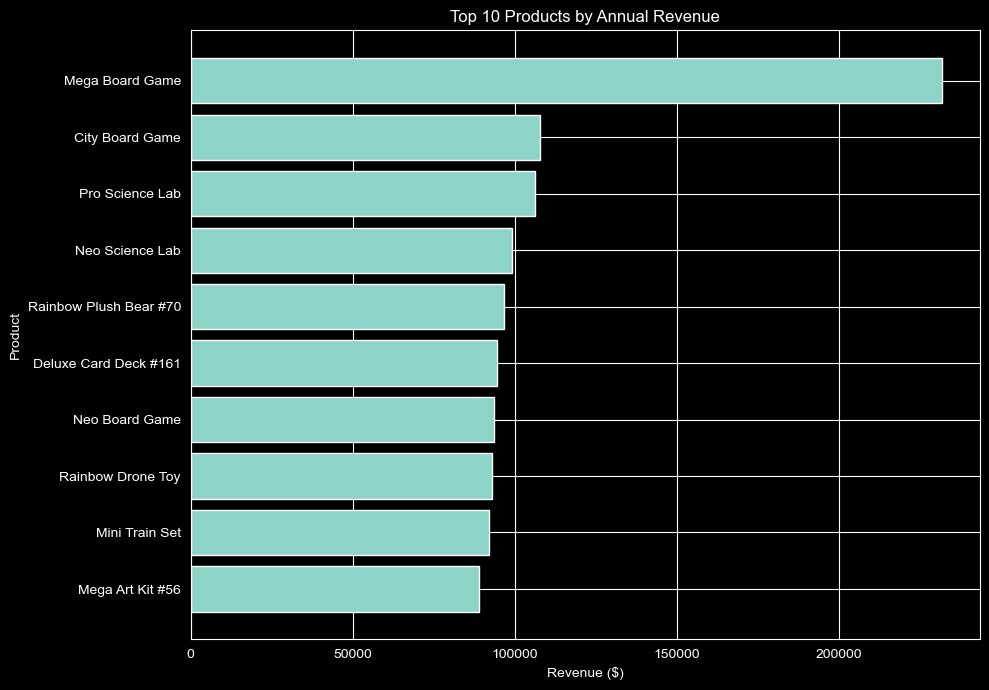

In [4]:
# Plot the top 10 products by annual revenue
revenue_plot = top_10_revenue.sort_values(
    "Revenue",
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    revenue_plot["Product_Name"],
    revenue_plot["Revenue"]
)
plt.title("Top 10 Products by Annual Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [5]:
# Identify the top 10 products by annual gross profit
top_10_profit = (
    product_summary
    .nlargest(10, "Gross_Profit")
    [
        [
            "Product_ID",
            "Product_Name",
            "Product_Category",
            "Units_Sold",
            "Revenue",
            "Gross_Profit",
            "Gross_Margin"
        ]
    ]
)

top_10_profit

,Product_ID,Product_Name,Product_Category,Units_Sold,Revenue,Gross_Profit,Gross_Margin
129,130,Mega Board Game,Action Figures,1623,231910.47,110006.94,0.474351
96,97,City Board Game,STEM Kits,2248,107791.60,51186.96,0.474870
130,131,Neo Board Game,Puzzles,2912,93533.44,49125.44,0.525218
55,56,Mega Art Kit #56,Card Games,2743,89092.64,46905.30,0.526478
5,6,Retro Science Lab,Action Figures,2790,83476.80,45086.40,0.540107
160,161,Deluxe Card Deck #161,Card Games,2257,94478.02,44485.47,0.470855
152,153,Pro Science Lab,Outdoor Play,2146,106205.54,43971.54,0.414023
113,114,Dino Puzzle Pack,Board Games,2786,79679.60,42430.78,0.532517
127,128,Galaxy Stacking Blocks,Toy Vehicles,3088,78589.60,41626.24,0.529666
52,53,Smart Card Deck,Baby & Toddler,2698,81884.30,41603.16,0.508072


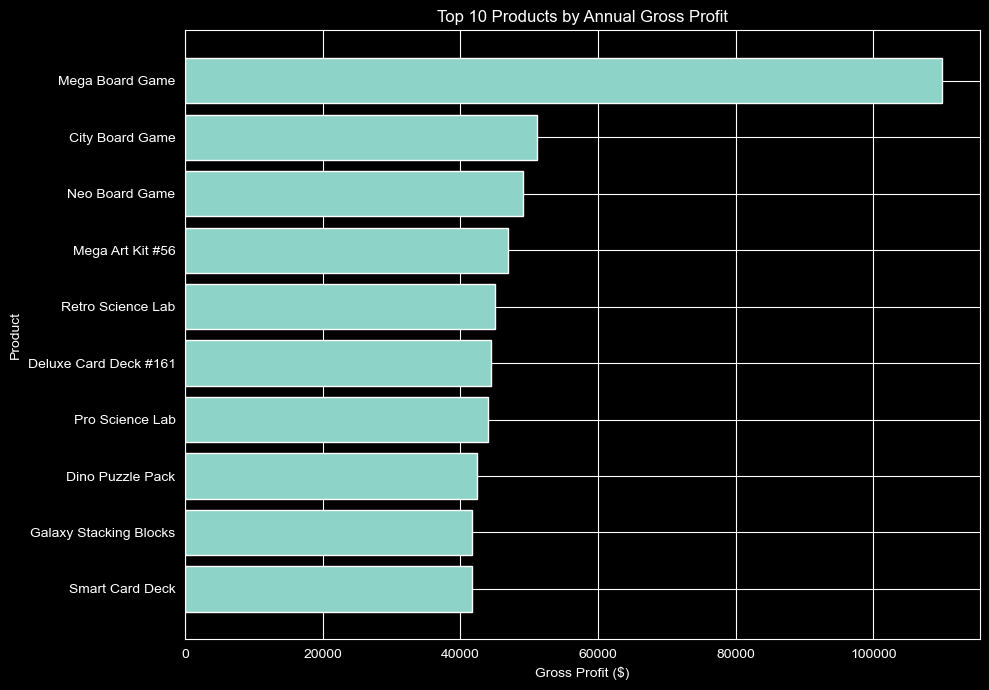

In [6]:
# Plot the top 10 products by annual gross profit
profit_plot = top_10_profit.sort_values(
    "Gross_Profit",
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    profit_plot["Product_Name"],
    profit_plot["Gross_Profit"]
)
plt.title("Top 10 Products by Annual Gross Profit")
plt.xlabel("Gross Profit ($)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [7]:
# Identify the top 10 products by annual units sold
top_10_units = (
    product_summary
    .nlargest(10, "Units_Sold")
    [
        [
            "Product_ID",
            "Product_Name",
            "Product_Category",
            "Units_Sold",
            "Revenue",
            "Gross_Profit",
            "Gross_Margin"
        ]
    ]
)

top_10_units

,Product_ID,Product_Name,Product_Category,Units_Sold,Revenue,Gross_Profit,Gross_Margin
117,118,Eco Art Kit,Baby & Toddler,4367,27730.45,10611.81,0.382677
60,61,Mini Robot,Arts & Crafts,4317,25945.17,8072.79,0.311148
98,99,Galaxy Train Set,Arts & Crafts,4201,36086.59,13905.31,0.385332
39,40,Dino Racing Car,Outdoor Play,4089,54220.14,20894.79,0.385370
66,67,Dino Castle,Building Blocks,4012,20060.00,7462.32,0.372000
10,11,Mini Farm Set,Building Blocks,3977,32850.02,12288.93,0.374092
164,165,Retro Explorer Kit,Baby & Toddler,3966,29427.72,8566.56,0.291105
169,170,Adventure Space Ship,Arts & Crafts,3930,32579.70,14619.60,0.448733
95,96,Mini Card Deck,Building Blocks,3913,35412.65,11582.48,0.327072
135,136,Deluxe Music Toy,Toy Vehicles,3898,23310.04,10719.50,0.459866


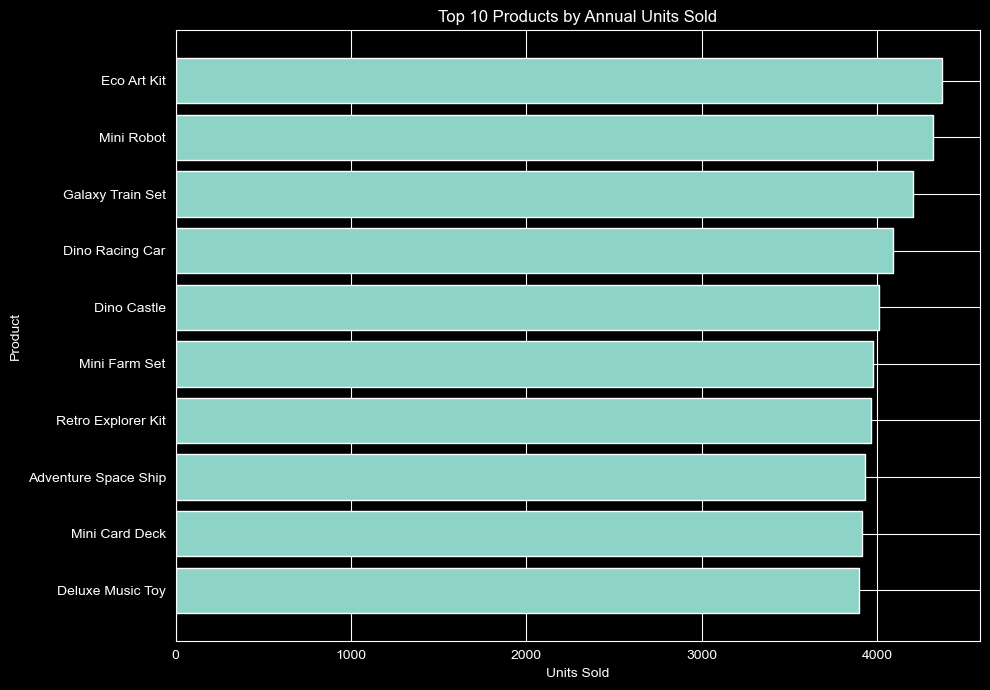

In [8]:
# Plot the top 10 products by annual units sold
units_plot = top_10_units.sort_values(
    "Units_Sold",
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    units_plot["Product_Name"],
    units_plot["Units_Sold"]
)
plt.title("Top 10 Products by Annual Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [9]:
# Calculate revenue and gross margin benchmarks for product segmentation
product_revenue_median = product_summary["Revenue"].median()
product_margin_median = product_summary["Gross_Margin"].median()

# Classify products into four business segments
def classify_product(row):
    if row["Revenue"] >= product_revenue_median and row["Gross_Margin"] >= product_margin_median:
        return "High Revenue / High Margin"
    elif row["Revenue"] >= product_revenue_median and row["Gross_Margin"] < product_margin_median:
        return "High Revenue / Low Margin"
    elif row["Revenue"] < product_revenue_median and row["Gross_Margin"] >= product_margin_median:
        return "Low Revenue / High Margin"
    else:
        return "Low Revenue / Low Margin"

product_summary["Segment"] = product_summary.apply(
    classify_product,
    axis=1
)

# Display the segmented products
product_summary[
    [
        "Product_ID",
        "Product_Name",
        "Product_Category",
        "Revenue",
        "Gross_Profit",
        "Gross_Margin",
        "Segment"
    ]
].sort_values(
    "Revenue",
    ascending=False
).head(20)

,Product_ID,Product_Name,Product_Category,Revenue,Gross_Profit,Gross_Margin,Segment
129,130,Mega Board Game,Action Figures,231910.47,110006.94,0.474351,High Revenue / High Margin
96,97,City Board Game,STEM Kits,107791.60,51186.96,0.474870,High Revenue / High Margin
152,153,Pro Science Lab,Outdoor Play,106205.54,43971.54,0.414023,High Revenue / Low Margin
134,135,Neo Science Lab,Pretend Play,99060.64,36901.92,0.372518,High Revenue / Low Margin
69,70,Rainbow Plush Bear #70,Pretend Play,96809.44,35804.32,0.369843,High Revenue / Low Margin
160,161,Deluxe Card Deck #161,Card Games,94478.02,44485.47,0.470855,High Revenue / High Margin
130,131,Neo Board Game,Puzzles,93533.44,49125.44,0.525218,High Revenue / High Margin
45,46,Rainbow Drone Toy,Action Figures,92972.08,38704.46,0.416302,High Revenue / Low Margin
168,169,Mini Train Set,Card Games,92022.00,39126.50,0.425186,High Revenue / Low Margin
55,56,Mega Art Kit #56,Card Games,89092.64,46905.30,0.526478,High Revenue / High Margin


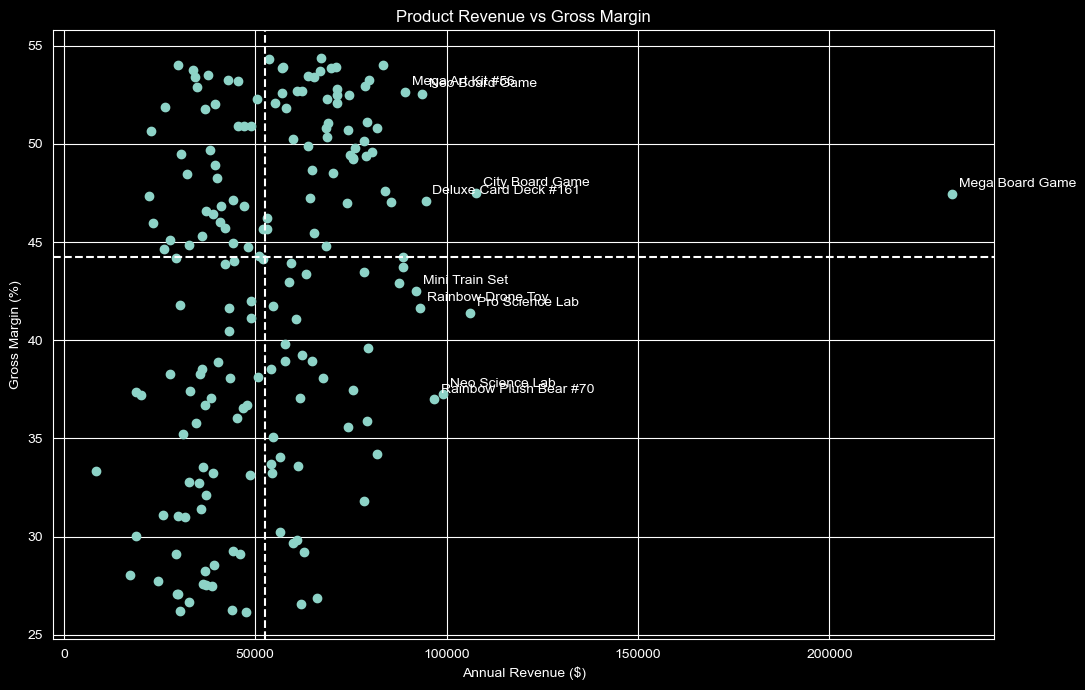

In [10]:
# Plot product revenue versus gross margin
plt.figure(figsize=(11, 7))

plt.scatter(
    product_summary["Revenue"],
    product_summary["Gross_Margin"] * 100
)

# Add labels only for the top 10 products by revenue
top_product_labels = product_summary.nlargest(10, "Revenue")

for _, row in top_product_labels.iterrows():
    plt.annotate(
        row["Product_Name"],
        (row["Revenue"], row["Gross_Margin"] * 100),
        xytext=(5, 5),
        textcoords="offset points"
    )

# Add median reference lines
plt.axvline(
    product_revenue_median,
    linestyle="--"
)

plt.axhline(
    product_margin_median * 100,
    linestyle="--"
)

plt.title("Product Revenue vs Gross Margin")
plt.xlabel("Annual Revenue ($)")
plt.ylabel("Gross Margin (%)")
plt.tight_layout()
plt.show()

In [11]:
# Calculate each product's contribution to total revenue
product_summary["Revenue_Share"] = (
    product_summary["Revenue"] /
    product_summary["Revenue"].sum()
)

# Rank products by revenue and calculate cumulative revenue share
product_summary = product_summary.sort_values(
    "Revenue",
    ascending=False
).reset_index(drop=True)

product_summary["Cumulative_Revenue_Share"] = (
    product_summary["Revenue_Share"].cumsum()
)

# Calculate revenue concentration for the top product groups
top_5_share = product_summary.head(5)["Revenue_Share"].sum()
top_10_share = product_summary.head(10)["Revenue_Share"].sum()
top_20_share = product_summary.head(20)["Revenue_Share"].sum()

print(f"Top 5 products revenue share: {top_5_share:.2%}")
print(f"Top 10 products revenue share: {top_10_share:.2%}")
print(f"Top 20 products revenue share: {top_20_share:.2%}")

Top 5 products revenue share: 6.51%
Top 10 products revenue share: 11.19%
Top 20 products revenue share: 19.72%


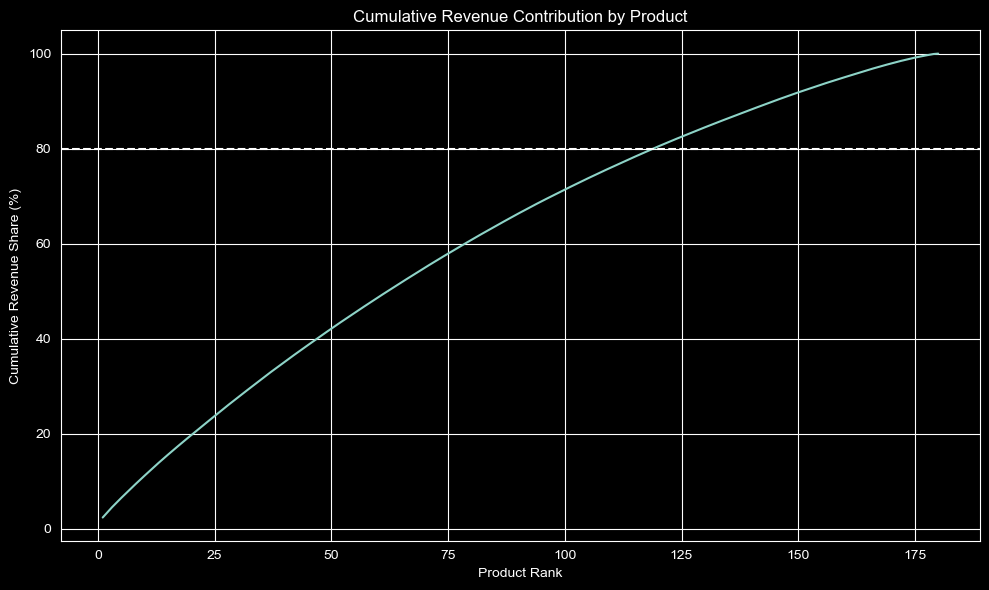

In [12]:
# Plot cumulative revenue contribution by product rank
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(product_summary) + 1),
    product_summary["Cumulative_Revenue_Share"] * 100
)

plt.axhline(
    80,
    linestyle="--"
)

plt.title("Cumulative Revenue Contribution by Product")
plt.xlabel("Product Rank")
plt.ylabel("Cumulative Revenue Share (%)")
plt.tight_layout()
plt.show()